In [111]:
%reload_ext autoreload
%autoreload 2

In [112]:
import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt

import flax.nnx as nnx
from probjax.nn.nets.mlp import MLP
from probjax.nn.nets.deepsets import DeepSet
from probjax.nn.nets.lru import LRULayer, LRU
from probjax.nn.nets.autoregressive import AutoregressiveMLP
from probjax.nn.nets.transformer import Transformer

from probjax.core import inverse_and_logabsdet


In [132]:
def bijector(x, y):
    return y*(jax.nn.sigmoid(x) + 0.1)


inverse_and_logabsdet(lambda x: bijector(x, 1.0))(jnp.array(2.0))


(Array([nan], dtype=float32), Array(-0.536, dtype=float32))

In [133]:
model = AutoregressiveMLP(10, 1, bijector, rngs=nnx.Rngs(0))

In [134]:
model.masked_mlp(x)

Array([ 0.   , -0.016,  0.009,  0.001, -0.037, -0.051,  0.107,  0.022,
        0.015, -0.104], dtype=float32)

In [135]:
x = jnp.ones((10,))
y = model(x)

In [136]:
model.inverse(y)

(Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32),
 Array(5.133, dtype=float32))

In [82]:
model(x)

Array([1.   , 0.971, 0.998, 1.026, 0.926, 0.851, 1.26 , 1.049, 1.016,
       0.951], dtype=float32)

In [93]:
y

Array([1.   , 0.971, 0.998, 1.026, 0.926, 0.851, 1.26 , 1.049, 1.016,
       0.951], dtype=float32)

In [97]:
from probjax.core.transformation import inverse_and_logabsdet


x = y
log_det = 0.0
for _ in range(model.in_out_dim):
    bij_params = model.mas(x, None)  # type: ignore
    print(bij_params)
    bijective_inv = inverse_and_logabsdet(lambda z: model.bijector(bij_params, z))
    x_, logabsdet_ = bijective_inv(y)
    print(x_)
    

AttributeError: 'AutoregressiveMLP' object has no attribute 'mas'

In [49]:
x

Array([ 1.   ,  1.262,  1.009,  0.757,  1.695,  2.24 , -1.504,  0.812,
        0.921,  2.172], dtype=float32)

In [6]:
model.inverse(y)

(Array([1.   , 0.854, 0.985, 1.128, 0.645, 0.189, 2.29 , 1.476, 1.102,
        1.109], dtype=float32),
 Array(0., dtype=float32))

In [18]:
class Model(nnx.Module):

    def __init__(self,dim, rngs):
        super().__init__()
        self.dim = dim
        self.linear = nnx.Linear(dim, dim, rngs=rngs)
        self.dropout = nnx.Dropout(0.1, rngs=rngs)

    def __call__(self, x):
        x = self.linear(x)
        x = self.dropout(x)
        return x

In [54]:
model = Model(10, rngs=nnx.Rngs(0))

In [58]:
graph_def, param, state = nnx.split(model,nnx.Param, nnx.Variable)

In [ ]:
#Get differentiable stuff...
params = nnx.state(model, nnx.Param)

In [70]:

model.train()
def loss_fn(params, model, x):
    nnx.update(model,params)
    return jnp.mean(model(x)**2)

In [16]:
model = MLP([1,10,1], rngs=nnx.Rngs(0))

In [33]:
model = AutoregressiveMLP([10, 50,20], rngs=nnx.Rngs(0))

In [40]:
nnx.MultiHeadAttention(4,10,4,4, rngs=nnx.Rngs(0))

MultiHeadAttention(
  num_heads=4,
  in_features=10,
  qkv_features=4,
  out_features=4,
  dtype=None,
  param_dtype=<class 'jax.numpy.float32'>,
  broadcast_dropout=True,
  dropout_rate=0.0,
  deterministic=None,
  precision=None,
  kernel_init=<function variance_scaling.<locals>.init at 0x7fc275ae4c20>,
  out_kernel_init=None,
  bias_init=<function zeros at 0x7fc276735760>,
  out_bias_init=None,
  use_bias=True,
  attention_fn=<function dot_product_attention at 0x7fc275ae59e0>,
  decode=None,
  normalize_qk=False,
  qkv_dot_general=None,
  out_dot_general=None,
  qkv_dot_general_cls=None,
  out_dot_general_cls=None,
  head_dim=1,
  query=LinearGeneral(
    in_features=(10,),
    out_features=(4, 1),
    axis=(-1,),
    batch_axis=FrozenDict({}),
    use_bias=True,
    dtype=None,
    param_dtype=<class 'jax.numpy.float32'>,
    kernel_init=<function variance_scaling.<locals>.init at 0x7fc275ae4c20>,
    bias_init=<function zeros at 0x7fc276735760>,
    precision=None,
    dot_general

In [45]:
nnx.initializers.variance_scaling

<function jax.nn.initializers.variance_scaling(scale: 'RealNumeric', mode: "Literal['fan_in'] | Literal['fan_out'] | Literal['fan_avg']", distribution: "Literal['truncated_normal'] | Literal['normal'] | Literal['uniform']", in_axis: 'int | Sequence[int]' = -2, out_axis: 'int | Sequence[int]' = -1, batch_axis: 'Sequence[int]' = (), dtype: 'DTypeLikeInexact' = <class 'jax.numpy.float64'>) -> 'Initializer'>

In [59]:
model = Transformer(10,4,2,4,rngs=nnx.Rngs(0))

In [66]:
import numpy as np
model(np.random.randn(*(1,1,10)))

Array([[[ 1.015,  0.334, -0.368, -1.041, -1.096, -1.614,  0.768, -0.223,
          1.712,  0.513]]], dtype=float32)

In [69]:
m = nnx.Dropout(0.5, rngs=nnx.Rngs(0))

In [ ]:
m.experimental_pytree

In [74]:
def loss(model,x):
    return jnp.sum(model(x))


nnx.grad(loss)(m, jnp.ones((10,)))

State({})

In [67]:
nnx.display(model)

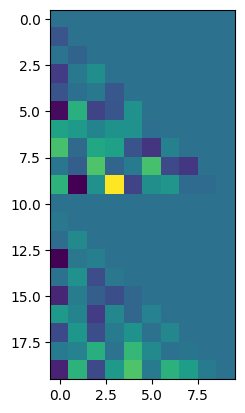

In [22]:
plt.imshow(jax.jacfwd(model)(jnp.ones((10,))))

In [5]:
deepset = DeepSet(MLP([1,10,10], rngs=nnx.Rngs(0)), MLP([10,10,1], rngs=nnx.Rngs(1)))

In [6]:
deepset(jnp.ones((1,10,1)))

Array([[-16.29]], dtype=float32)

In [7]:
lru1 = LRU(1,100,10, rngs=nnx.Rngs(0))
l1 = LRULayer(lru1, 1, rngs=nnx.Rngs(1))
lru2 = LRU(1,100,10, rngs=nnx.Rngs(2))
l2 = LRULayer(lru2, 1, rngs=nnx.Rngs(3))


class Model(nnx.Module, experimental_pytree=True):
    def __init__(self):
        self.l1 = l1
        self.l2 = l2
    def __call__(self, x):
        return self.l2(self.l1(x))
    
model = Model()

nnx.display(model)

In [15]:
model = nnx.MultiHeadAttention(4, 1, 4, 1, rngs=nnx.Rngs(0))
nnx.display(model)

In [25]:
model(jnp.ones((1,10,1)), decode=False)

Array([[[-0.231],
        [-0.231],
        [-0.231],
        [-0.231],
        [-0.231],
        [-0.231],
        [-0.231],
        [-0.231],
        [-0.231],
        [-0.231]]], dtype=float32)

In [29]:
from jax.experimental import pallas as pl 
from jax.experimental.pallas.ops.gpu.attention

SyntaxError: invalid syntax (4122328513.py, line 2)

In [41]:
jax.nn.dot_product_attention(jnp.ones((1,8,1,1), dtype=jnp.float16), jnp.ones((1,8,1,1),dtype=jnp.float16), jnp.ones((1,8,1,1),dtype=jnp.float16), implementation="cudnn")

NotImplementedError: Unsupported sequence length Q 8, KV 8 and head dim 1.